## Libraries and Data Import

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:

!pip install spikingjelly scikit-learn numpy pandas matplotlib tensorflow torch

# Import required libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Scikit-learn libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, precision_score,
    recall_score, f1_score, roc_curve, auc, matthews_corrcoef
)
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC

# Define a function to print evaluation metrics
def get_metrics(y_pred, y_true):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Confusion Matrix": confusion_matrix(y_true, y_pred),
        "Classification Report": classification_report(y_true, y_pred)
    }


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 12.2 MB/s eta 0:00:00


In [9]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DTI/data/classification_model_data.csv')
data.head(5)

,SubFP1,SubFP2,SubFP3,SubFP4,SubFP5,SubFP6,SubFP7,SubFP8,SubFP9,SubFP10,...,SubFP299,SubFP300,SubFP301,SubFP302,SubFP303,SubFP304,SubFP305,SubFP306,SubFP307,activity_class
0,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,1,active
1,1,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,1,inactive
2,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,1,active
3,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,1,active
4,0,0,0,0,0,0,0,0,0,0,...,0,1,1,1,0,0,0,0,1,active


In [10]:
features = data.drop(columns = ['activity_class'])
targets = data.activity_class

In [11]:
X_training_set, X_validation_set, y_training_set, y_validation_set = train_test_split(
    features, targets, test_size=0.2, random_state=42 )
X_training_set = np.array(X_training_set)
X_validation_set = np.array(X_validation_set)

y_training_set = np.array(y_training_set)
y_validation_set = np.array(y_validation_set)


In [12]:
def remove_low_variance(input_data, threshold=0.1):
    selection = VarianceThreshold(threshold)
    selection.fit(input_data)
    return input_data[input_data.columns[selection.get_support(indices=True)]]


features = remove_low_variance(features, threshold=0.1)
features.head(5)

,SubFP1,SubFP2,SubFP3,SubFP20,SubFP38,SubFP49,SubFP85,SubFP88,SubFP96,SubFP100,SubFP135,SubFP137,SubFP171,SubFP181,SubFP182,SubFP183,SubFP184,SubFP279,SubFP280,SubFP287
0,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,0,1
1,1,0,0,0,0,1,0,1,0,0,1,1,0,1,1,0,1,0,0,1
2,0,0,0,0,0,1,0,1,0,0,1,1,0,0,1,0,1,0,0,1
3,0,0,0,0,0,1,0,1,0,0,1,1,0,0,1,0,1,0,0,1
4,0,0,0,0,0,1,0,1,0,0,1,1,0,0,0,1,1,0,0,1


# Models Building and Training

In [13]:
def get_metrics(predicted,true):
    metrics = dict()
    metrics['accuracy'] = round(accuracy_score(predicted, true), 5)
    metrics['precision'] = round(precision_score(predicted, true, average = 'weighted'), 5)
    metrics['recall'] = round(recall_score(predicted, true, average = 'weighted'), 5)
    metrics['f1'] = round(f1_score(predicted, true, average = 'weighted'), 5)

    return metrics

## Random Forest Classifier
Splitting the Data into training and validation sets. 80% training and 20% validation should be a good split in this case.

In [14]:
X_training_set, X_validation_set, y_training_set, y_validation_set = train_test_split(features, targets, test_size=0.2, random_state=42)

Create Random Forest Classifier and fit it to the training data.

In [15]:
RF_model = RandomForestClassifier(n_estimators=500, random_state=42)
RF_model.fit(X_training_set, y_training_set)

RandomForestClassifier(n_estimators=500, random_state=42)

Make some predictions on training and validation data to tests for Mathews Correlation values.

In [16]:
y_training_pred = RF_model.predict(X_training_set)
y_validation_pred = RF_model.predict(X_validation_set)

In [17]:
RF_mcc_test = matthews_corrcoef(y_validation_set, y_validation_pred)
RF_mcc_test

np.float64(0.7774957785358391)

Calculate alternative accuracy metrics. Accuracy, Precision, Recall, and F1-Score.

In [18]:
RF_metrics = pd.DataFrame([get_metrics(y_validation_pred, y_validation_set)])
RF_metrics

,accuracy,precision,recall,f1
0,0.88889,0.89226,0.88889,0.88935


## Support Vector Machine Classifier

Initialize Support Vector Machine Classifier (SVC) as Linear SVC.
Fit SVM to training data.

In [19]:
SVM_classifier = LinearSVC()
SVM_classifier.fit(X_training_set, y_training_set)

LinearSVC()

Make some predictions with SVM classifier.

In [20]:
y_SVM_pred = SVM_classifier.predict(X_validation_set)
SVM_metrics = pd.DataFrame([get_metrics(y_SVM_pred, y_validation_set)])
SVM_metrics

,accuracy,precision,recall,f1
0,0.90741,0.91438,0.90741,0.90809


## Convolutional Neural Network (CNN)

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from spikingjelly.clock_driven import neuron
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Reshape input for CNN
X_train_tensor = torch.tensor(X_training_set.values, dtype=torch.float32).view(-1, 1, X_training_set.shape[1], 1)
y_train_tensor = torch.tensor(pd.factorize(y_training_set)[0], dtype=torch.long)

X_val_tensor = torch.tensor(X_validation_set.values, dtype=torch.float32).view(-1, 1, X_validation_set.shape[1], 1)
y_val_tensor = torch.tensor(pd.factorize(y_validation_set)[0], dtype=torch.long)

# Define CNN Model
class CNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 1), padding=(1, 0))
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 1))
        self.fc1 = nn.Linear(16 * (input_dim // 2), 128)
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize CNN Model
cnn_model = CNN(input_dim=X_train_tensor.shape[2], output_dim=len(torch.unique(y_train_tensor)))

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Training Loop
epochs = 10
for epoch in range(epochs):
    optimizer.zero_grad()
    output = cnn_model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Evaluation
cnn_model.eval()
with torch.no_grad():
    cnn_output = cnn_model(X_val_tensor)
    _, cnn_predictions = torch.max(cnn_output, 1)

    # Compute evaluation metrics
    accuracy = accuracy_score(y_val_tensor.numpy(), cnn_predictions.numpy())
    precision = precision_score(y_val_tensor.numpy(), cnn_predictions.numpy(), average='weighted', zero_division=1)
    recall = recall_score(y_val_tensor.numpy(), cnn_predictions.numpy(), average='weighted', zero_division=1)
    f1 = f1_score(y_val_tensor.numpy(), cnn_predictions.numpy(), average='weighted')

# Print Evaluation Metrics
print(f" CNN Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Epoch 1, Loss: 0.6980782747268677
Epoch 2, Loss: 0.6853837966918945
Epoch 3, Loss: 0.6748023629188538
Epoch 4, Loss: 0.6656035780906677
Epoch 5, Loss: 0.6570208072662354
Epoch 6, Loss: 0.648489773273468
Epoch 7, Loss: 0.639713704586029
Epoch 8, Loss: 0.630838930606842
Epoch 9, Loss: 0.6219032406806946
Epoch 10, Loss: 0.6127665638923645
 CNN Metrics:
Accuracy: 0.7778
Precision: 0.8177
Recall: 0.7778
F1 Score: 0.7663


## Decision Tree

In [22]:
from sklearn.tree import DecisionTreeClassifier

# Train Decision Tree Classifier
DT_model = DecisionTreeClassifier(random_state=42)
DT_model.fit(X_training_set, y_training_set)

# Evaluate Decision Tree
DT_predictions = DT_model.predict(X_validation_set)
DT_metrics = get_metrics(DT_predictions, y_validation_set)
print("Decision Tree Metrics:", DT_metrics)

Decision Tree Metrics: {'accuracy': 0.88889, 'precision': 0.89226, 'recall': 0.88889, 'f1': 0.88935}


 ## K-Nearest Neighbors (KNN)

In [23]:

from sklearn.neighbors import KNeighborsClassifier

# Train KNN Classifier (k=5)
KNN_model = KNeighborsClassifier(n_neighbors=5)
KNN_model.fit(X_training_set, y_training_set)


# Evaluate KNN
KNN_predictions = KNN_model.predict(X_validation_set)
KNN_metrics = get_metrics(KNN_predictions, y_validation_set)
print("KNN Metrics:", KNN_metrics)


KNN Metrics: {'accuracy': 0.90741, 'precision': 0.90835, 'recall': 0.90741, 'f1': 0.90757}


## Spiking Neural Network (SNN)

In [24]:

X_train_tensor = torch.tensor(X_training_set.values, dtype=torch.float32) # Get the values from the DataFrame
y_train_tensor = torch.tensor(pd.factorize(y_training_set)[0], dtype=torch.long)

X_val_tensor = torch.tensor(X_validation_set.values, dtype=torch.float32) # Get the values from the DataFrame
y_val_tensor = torch.tensor(pd.factorize(y_validation_set)[0], dtype=torch.long)

# Ensure input shapes match
print(f"Training Data Shape: {X_train_tensor.shape}")
print(f"Validation Data Shape: {X_val_tensor.shape}")

# Define Spiking Neural Network (SNN)
class SNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.lif1 = neuron.LIFNode()  # Spiking activation
        self.fc2 = nn.Linear(128, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.lif1(x)
        self.lif1.v = 0  # Reset membrane potential after spike
        x = self.fc2(x)
        return x

# Initialize Model
snn_model = SNN(input_dim=X_train_tensor.shape[1], output_dim=len(torch.unique(y_train_tensor)))

# Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(snn_model.parameters(), lr=0.001)

# Training Loop
epochs = 10
for epoch in range(epochs):
    optimizer.zero_grad()
    output = snn_model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

# Evaluation
snn_model.eval()  # Set model to evaluation mode
with torch.no_grad():
    snn_output = snn_model(X_val_tensor)
    _, snn_predictions = torch.max(snn_output, 1)

    # Convert to NumPy arrays for metrics computation
    y_true_np = y_val_tensor.numpy()
    y_pred_np = snn_predictions.numpy()

    # Compute evaluation metrics
    accuracy = accuracy_score(y_true_np, y_pred_np)
    precision = precision_score(y_true_np, y_pred_np, average='weighted', zero_division=1)
    recall = recall_score(y_true_np, y_pred_np, average='weighted', zero_division=1)
    f1 = f1_score(y_true_np, y_pred_np, average='weighted')

# Print Evaluation Metrics
print(f"SNN Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")


Training Data Shape: torch.Size([214, 20])
Validation Data Shape: torch.Size([54, 20])
Epoch 1, Loss: 0.6990237832069397
Epoch 2, Loss: 0.6988812685012817
Epoch 3, Loss: 0.6987396478652954
Epoch 4, Loss: 0.6985992193222046
Epoch 5, Loss: 0.6984597444534302
Epoch 6, Loss: 0.6983212828636169
Epoch 7, Loss: 0.698184072971344
Epoch 8, Loss: 0.6980477571487427
Epoch 9, Loss: 0.6979126930236816
Epoch 10, Loss: 0.6977787613868713
SNN Metrics:
Accuracy: 0.4630
Precision: 0.7514
Recall: 0.4630
F1 Score: 0.2930


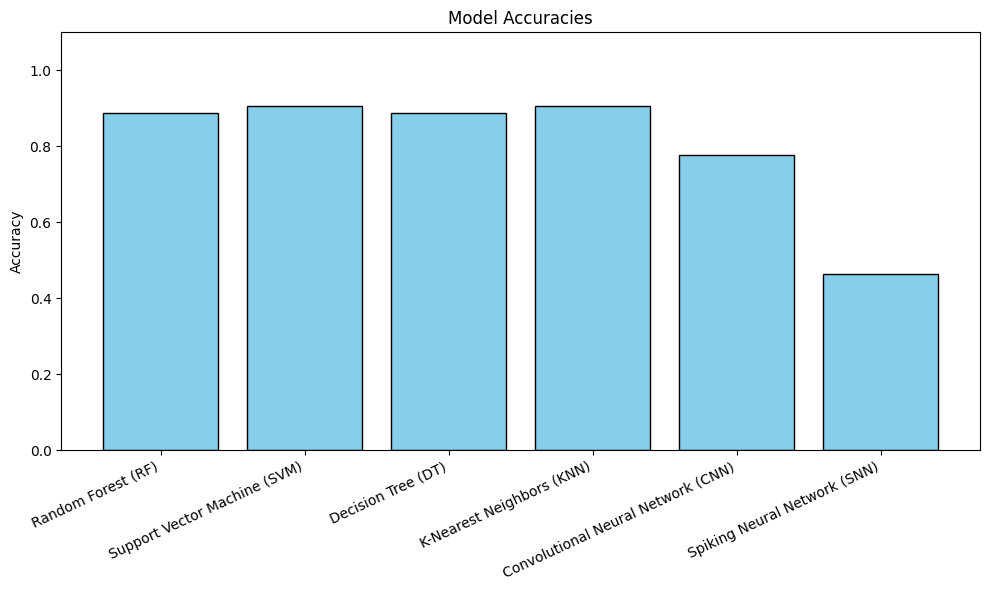

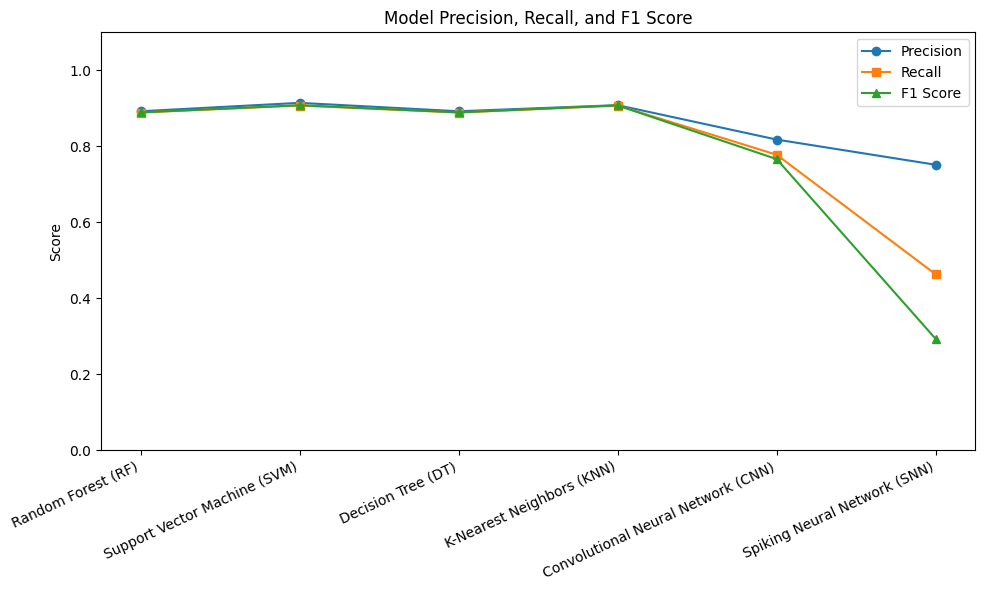

In [25]:
import matplotlib.pyplot as plt

# Final metrics dictionary
metrics = {
    "Random Forest (RF)": {
        "Accuracy": 0.88889,
        "Precision": 0.89226,
        "Recall": 0.88889,
        "F1 Score": 0.88935
    },
    "Support Vector Machine (SVM)": {
        "Accuracy": 0.90741,
        "Precision": 0.91438,
        "Recall": 0.90741,
        "F1 Score": 0.90809
    },
    "Decision Tree (DT)": {
        "Accuracy": 0.88889,
        "Precision": 0.89226,
        "Recall": 0.88889,
        "F1 Score": 0.88935
    },
    "K-Nearest Neighbors (KNN)": {
        "Accuracy": 0.90741,
        "Precision": 0.90835,
        "Recall": 0.90741,
        "F1 Score": 0.90757
    },
    "Convolutional Neural Network (CNN)": {
        "Accuracy": 0.7778,
        "Precision": 0.8177,
        "Recall": 0.7778,
        "F1 Score": 0.7663
    },
    "Spiking Neural Network (SNN)": {
        "Accuracy": 0.4630,
        "Precision": 0.7514,
        "Recall": 0.4630,
        "F1 Score": 0.2930
    }
}

# Extract model names
models = list(metrics.keys())

# Accuracy values (for bar chart)
accuracies = [metrics[m]["Accuracy"] for m in models]

# Other metrics (for line chart)
precisions = [metrics[m]["Precision"] for m in models]
recalls    = [metrics[m]["Recall"] for m in models]
f1_scores  = [metrics[m]["F1 Score"] for m in models]

# --- Bar chart for accuracies ---
plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color="skyblue", edgecolor="black")
plt.title("Model Accuracies")
plt.ylabel("Accuracy")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

# --- Line chart for Precision, Recall, F1 ---
plt.figure(figsize=(10, 6))
plt.plot(models, precisions, marker="o", label="Precision")
plt.plot(models, recalls, marker="s", label="Recall")
plt.plot(models, f1_scores, marker="^", label="F1 Score")

plt.title("Model Precision, Recall, and F1 Score")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()
